
# 01 – Financial Data Preparation & Baseline Modelling

This notebook prepares the **financial dataset** and estimates **baseline ARX / VAR models** without any emotion-based variables.

It:

1. Loads raw OHLCV financial data (Bitcoin, Gold, Crude Oil, S&P 500, FX, 10Y yield).
2. Cleans and aligns the series on a common daily index.
3. Constructs **log returns** and **control variables** (FX, oil, yield).
4. Performs basic exploratory analysis and stationarity checks.
5. Estimates baseline **ARX** (per asset) and a multivariate **VAR** model.
6. Exports a tidy dataset for use in the emotion/EPI notebook.

> **Note:** You may need to adjust file paths and column names to match your actual data.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
import statsmodels.api as sm

# Display and plotting options
pd.options.display.float_format = "{:.4f}".format
plt.rcParams["figure.figsize"] = (10, 4)

DATA_DIR = "./data/"
OUTPUT_DIR = "./data/"

RAW_FINANCIAL_FILE = DATA_DIR + "market_data.json"
FINANCIAL_PANEL_FILE = OUTPUT_DIR + "financial_returns_and_controls.parquet"
FINANCIAL_PANEL_CSV = OUTPUT_DIR + "financial_returns_and_controls.csv"

# Analysis window
START_DATE = "2025-01-01"
END_DATE = "2025-05-31"



## 1. Load raw financial data

Expected structure (example):

```json
{
  "Date_": "2024-11-19 00:00:00",
  "Close_BTC-USD": ...,
  "High_BTC-USD": ...,
  "Low_BTC-USD": ...,
  "Open_BTC-USD": ...,
  "Volume_BTC-USD": ...,
  ...
}
```


In [2]:

# --- Load raw data ---
# If your file is CSV, use read_csv instead.
try:
    df_raw = pd.read_json(RAW_FINANCIAL_FILE)
except ValueError:
    df_raw = pd.read_csv(RAW_FINANCIAL_FILE)

# Basic cleaning: parse dates and sort
if "Date_" in df_raw.columns:
    df_raw["Date_"] = pd.to_datetime(df_raw["Date_"])
    df_raw = df_raw.sort_values("Date_").set_index("Date_")
else:
    # Adjust here if your date column has a different name
    raise KeyError("Expected a 'Date_' column. Please adjust the code to your date column name.")

print(df_raw.head())
print(df_raw.info())


            Close_BTC-USD  Close_CL=F  Close_CNY=X  Close_EUR=X  Close_GC=F  \
Date_                                                                         
2024-11-18            NaN         NaN          NaN          NaN         NaN   
2024-11-19     92343.7891     69.3900       7.2354       0.9438   2627.1001   
2024-11-20     94339.4922     68.8700       7.2381       0.9427   2648.2000   
2024-11-21     98504.7266     70.1000       7.2440       0.9482   2672.1001   
2024-11-22     98997.6641     71.2400       7.2337       0.9552   2709.8999   

            Close_^GSPC  Close_^TNX  High_BTC-USD  High_CL=F  High_CNY=X  ...  \
Date_                                                                     ...   
2024-11-18          NaN      4.4140           NaN        NaN         NaN  ...   
2024-11-19    5916.9800      4.3790    94002.8672    69.6900      7.2428  ...   
2024-11-20    5917.1099      4.4060    94902.0234    70.1500      7.2461  ...   
2024-11-21    5948.7100      4.4320    99


## 2. Sanity checks & renaming

We rename columns to simpler names (e.g. `close_btc`, `close_gold`, etc.) so they are easier to work with.


In [3]:

# Inspect available columns
df_raw.columns


Index(['Close_BTC-USD', 'Close_CL=F', 'Close_CNY=X', 'Close_EUR=X',
       'Close_GC=F', 'Close_^GSPC', 'Close_^TNX', 'High_BTC-USD', 'High_CL=F',
       'High_CNY=X', 'High_EUR=X', 'High_GC=F', 'High_^GSPC', 'High_^TNX',
       'Low_BTC-USD', 'Low_CL=F', 'Low_CNY=X', 'Low_EUR=X', 'Low_GC=F',
       'Low_^GSPC', 'Low_^TNX', 'Open_BTC-USD', 'Open_CL=F', 'Open_CNY=X',
       'Open_EUR=X', 'Open_GC=F', 'Open_^GSPC', 'Open_^TNX', 'Volume_BTC-USD',
       'Volume_CL=F', 'Volume_CNY=X', 'Volume_EUR=X', 'Volume_GC=F',
       'Volume_^GSPC', 'Volume_^TNX'],
      dtype='object')

In [4]:

# Define a renaming map; extend / adjust as needed
rename_map = {
    "Close_BTC-USD": "close_btc",
    "Open_BTC-USD": "open_btc",
    "High_BTC-USD": "high_btc",
    "Low_BTC-USD": "low_btc",
    "Volume_BTC-USD": "vol_btc",

    "Close_GC=F": "close_gold",
    "Open_GC=F": "open_gold",
    "High_GC=F": "high_gold",
    "Low_GC=F": "low_gold",
    "Volume_GC=F": "vol_gold",

    "Close_CL=F": "close_oil",
    "Open_CL=F": "open_oil",
    "High_CL=F": "high_oil",
    "Low_CL=F": "low_oil",
    "Volume_CL=F": "vol_oil",

    "Close_^GSPC": "close_spx",
    "Open_^GSPC": "open_spx",
    "High_^GSPC": "high_spx",
    "Low_^GSPC": "low_spx",
    "Volume_^GSPC": "vol_spx",

    "Close_CNY=X": "close_usdcny",
    "Open_CNY=X": "open_usdcny",
    "High_CNY=X": "high_usdcny",
    "Low_CNY=X": "low_usdcny",
    "Volume_CNY=X": "vol_usdcny",

    "Close_EUR=X": "close_eurusd",
    "Open_EUR=X": "open_eurusd",
    "High_EUR=X": "high_eurusd",
    "Low_EUR=X": "low_eurusd",
    "Volume_EUR=X": "vol_eurusd",

    "Close_^TNX": "close_ust10y",
    "Open_^TNX": "open_ust10y",
    "High_^TNX": "high_ust10y",
    "Low_^TNX": "low_ust10y",
    "Volume_^TNX": "vol_ust10y",
}

df = df_raw.rename(columns=rename_map)

print("After renaming:")
print(df.head())


After renaming:
            close_btc  close_oil  close_usdcny  close_eurusd  close_gold  \
Date_                                                                      
2024-11-18        NaN        NaN           NaN           NaN         NaN   
2024-11-19 92343.7891    69.3900        7.2354        0.9438   2627.1001   
2024-11-20 94339.4922    68.8700        7.2381        0.9427   2648.2000   
2024-11-21 98504.7266    70.1000        7.2440        0.9482   2672.1001   
2024-11-22 98997.6641    71.2400        7.2337        0.9552   2709.8999   

            close_spx  close_ust10y   high_btc  high_oil  high_usdcny  ...  \
Date_                                                                  ...   
2024-11-18        NaN        4.4140        NaN       NaN          NaN  ...   
2024-11-19  5916.9800        4.3790 94002.8672   69.6900       7.2428  ...   
2024-11-20  5917.1099        4.4060 94902.0234   70.1500       7.2461  ...   
2024-11-21  5948.7100        4.4320 99014.2188   70.3800     

## 3. Align frequencies and handle non-trading days

We keep the native trading-day calendar (no synthetic weekend/holiday rows). Prices are forward-filled within existing rows only, and a flag marks rows that needed filling.

In [5]:
# Create a continuous business-day index over the sample
full_index = pd.date_range(df.index.min(), df.index.max(), freq="B")
df = df.reindex(full_index)

# Identify price and volume columns
price_cols = [c for c in df.columns if c.startswith(("close_", "open_", "high_", "low_"))]
volume_cols = [c for c in df.columns if c.startswith("vol_")]

# Track rows where prices were missing prior to forward-fill
missing_price_rows = df[price_cols].isna().any(axis=1)

# Forward-fill prices, leave volumes as-is
df[price_cols] = df[price_cols].ffill()

# Flag rows that relied on forward-filled prices
df["ffill_flag"] = missing_price_rows

print(df.head())


            close_btc  close_oil  close_usdcny  close_eurusd  close_gold  \
2024-11-18        NaN        NaN           NaN           NaN         NaN   
2024-11-19 92343.7891    69.3900        7.2354        0.9438   2627.1001   
2024-11-20 94339.4922    68.8700        7.2381        0.9427   2648.2000   
2024-11-21 98504.7266    70.1000        7.2440        0.9482   2672.1001   
2024-11-22 98997.6641    71.2400        7.2337        0.9552   2709.8999   

            close_spx  close_ust10y   high_btc  high_oil  high_usdcny  ...  \
2024-11-18        NaN        4.4140        NaN       NaN          NaN  ...   
2024-11-19  5916.9800        4.3790 94002.8672   69.6900       7.2428  ...   
2024-11-20  5917.1099        4.4060 94902.0234   70.1500       7.2461  ...   
2024-11-21  5948.7100        4.4320 99014.2188   70.3800       7.2459  ...   
2024-11-22  5969.3398        4.4100 99655.5000   71.5100       7.2487  ...   

            open_spx  open_ust10y           vol_btc     vol_oil  vol_usdcn


## 4. Construct returns and control variables

We compute:

- **Log returns** for Bitcoin, Gold, S&P 500.
- **Log differences** for FX and oil.
- **First difference** for the 10-year yield.


In [6]:

def log_return(series):
    return np.log(series).diff()

returns = pd.DataFrame(index=df.index)

# Asset returns
returns["r_btc"] = log_return(df["close_btc"])
returns["r_gold"] = log_return(df["close_gold"])
returns["r_spx"] = log_return(df["close_spx"])

# Control variables
returns["dln_eurusd"] = log_return(df["close_eurusd"])   # USD/EUR
returns["dln_usdcny"] = log_return(df["close_usdcny"])   # USD/CNY
returns["dln_oil"] = log_return(df["close_oil"])
returns["dy10"] = df["close_ust10y"].diff()

# Drop initial NaNs from differencing
returns = returns.dropna()

# Restrict to analysis window
returns = returns.loc[START_DATE:END_DATE]

returns.head()


,r_btc,r_gold,r_spx,dln_eurusd,dln_usdcny,dln_oil,dy10
2025-01-01,0.0105,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2025-01-02,0.0258,0.0112,-0.0022,0.0052,0.0000,0.0195,0.0020
2025-01-03,0.0125,-0.0052,0.0125,0.0081,0.0001,0.0113,0.0210
2025-01-06,0.0397,-0.0025,0.0055,-0.0036,0.0029,-0.0054,0.0220
2025-01-07,-0.0518,0.0069,-0.0112,-0.0078,0.0004,0.0093,0.0650


## 4b. Load and merge EPI data

Load the Emotion Polarity Index (EPI) and topic-weighted EPI data exported from `300_index_module.ipynb`.

In [7]:
# Load EPI data from JSON
EPI_FILE = DATA_DIR + "epi_data.json"

df_epi = pd.read_json(EPI_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

print("EPI data loaded:")
print(f"Columns: {df_epi.columns.tolist()}")
print(f"Date range: {df_epi.index.min()} to {df_epi.index.max()}")
print(df_epi.head())

EPI data loaded:
Columns: ['ei_creator', 'ei_community', 'epi', 'epi_weighted', 'epi_', 'epi_Environmental and Infrastructure', 'epi_Labor and Workforce', 'epi_Health and Social Welfare', 'epi_Legal and Regulatory Framework', 'epi_Education and Knowledge', 'epi_Psychological and Emotional Aspects', 'epi_Leadership and Governance', 'epi_Economic and Financial Matters', 'epi_Disaster and Resilience', 'epi_Security and Conflict', 'epi_Disputes and Opinions', 'epi_Miscellaneous and Other', 'epi_Sports and Recreation', 'epi_Power and Influence Dynamics', 'epi_Social and Cultural Aspects', 'epi_Quality of Life and Standards', 'epi_Trust, Credibility, and Communication', 'epi_Conspiracy and Historical Events']
Date range: 2025-01-02 00:00:00 to 2025-05-31 00:00:00
            ei_creator  ei_community     epi  epi_weighted    epi_  \
date                                                                 
2025-01-02      1.0000        0.0000 -1.0000       -1.0000  0.0000   
2025-01-04     -1.0000

In [8]:
# Merge EPI data with returns dataframe
# EPI columns to include: epi (main EPI), epi_weighted (topic-weighted EPI), and topic-specific EPIs
epi_cols = [col for col in df_epi.columns if col.startswith('epi') or col in ['ei_creator', 'ei_community']]

# Merge on index (date)
returns = returns.join(df_epi[epi_cols], how='left')

# Fill missing EPI values with 0 (neutral) for dates without EPI data
returns[epi_cols] = returns[epi_cols].fillna(0)

print("Returns with EPI data:")
print(f"Shape: {returns.shape}")
print(f"Columns: {returns.columns.tolist()}")
print(returns.head())

Returns with EPI data:
Shape: (108, 30)
Columns: ['r_btc', 'r_gold', 'r_spx', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'ei_creator', 'ei_community', 'epi', 'epi_weighted', 'epi_', 'epi_Environmental and Infrastructure', 'epi_Labor and Workforce', 'epi_Health and Social Welfare', 'epi_Legal and Regulatory Framework', 'epi_Education and Knowledge', 'epi_Psychological and Emotional Aspects', 'epi_Leadership and Governance', 'epi_Economic and Financial Matters', 'epi_Disaster and Resilience', 'epi_Security and Conflict', 'epi_Disputes and Opinions', 'epi_Miscellaneous and Other', 'epi_Sports and Recreation', 'epi_Power and Influence Dynamics', 'epi_Social and Cultural Aspects', 'epi_Quality of Life and Standards', 'epi_Trust, Credibility, and Communication', 'epi_Conspiracy and Historical Events']
             r_btc  r_gold   r_spx  dln_eurusd  dln_usdcny  dln_oil   dy10  \
2025-01-01  0.0105  0.0000  0.0000      0.0000      0.0000   0.0000 0.0000   
2025-01-02  0.0258  0.0112 -0.002


## 5. Exploratory data analysis

Time-series plots, summary statistics, and correlations.


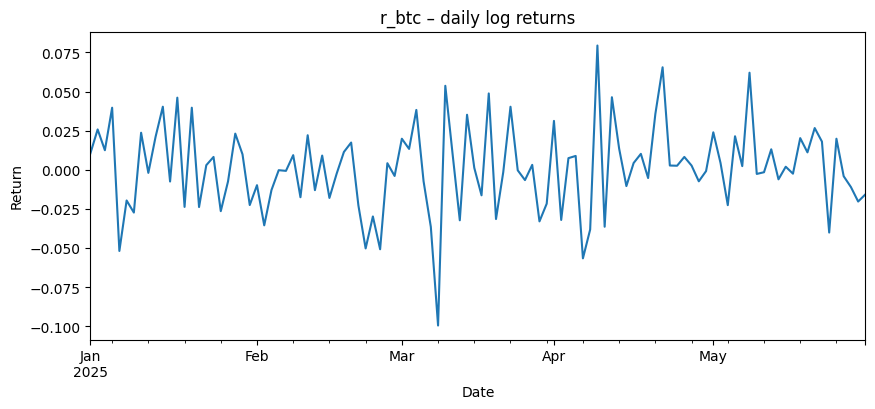

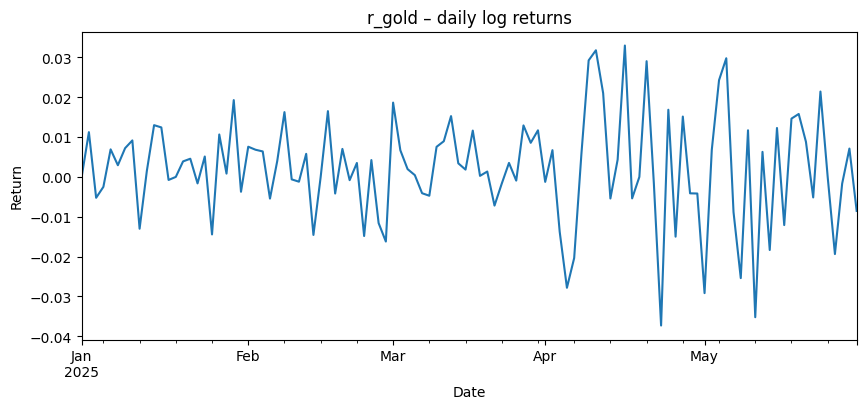

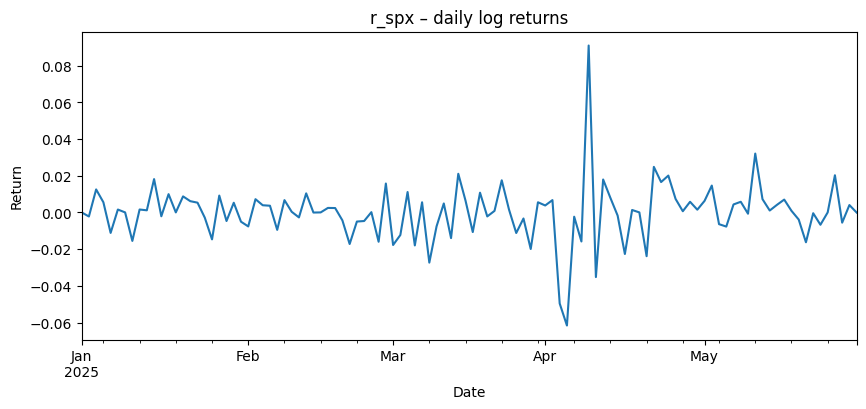

In [9]:

# Plot returns
for col in ["r_btc", "r_gold", "r_spx"]:
    ax = returns[col].plot(title=f"{col} – daily log returns")
    ax.set_xlabel("Date")
    ax.set_ylabel("Return")
    plt.show()


In [10]:

# Summary statistics
returns.describe().T


,count,mean,std,min,25%,50%,75%,max
r_btc,108.0000,0.0010,0.0280,-0.0994,-0.0166,0.0016,0.0176,0.0794
r_gold,108.0000,0.0021,0.0133,-0.0373,-0.0042,0.0024,0.0090,0.0330
r_spx,108.0000,0.0000,0.0161,-0.0616,-0.0052,0.0007,0.0063,0.0909
dln_eurusd,108.0000,-0.0008,0.0062,-0.0275,-0.0042,0.0003,0.0026,0.0145
dln_usdcny,108.0000,-0.0001,0.0026,-0.0113,-0.0003,0.0000,0.0007,0.0123
dln_oil,108.0000,-0.0015,0.0200,-0.0770,-0.0153,0.0000,0.0096,0.0454
dy10,108.0000,-0.0015,0.0600,-0.1410,-0.0430,0.0000,0.0340,0.1700
ei_creator,108.0000,-0.0664,0.2839,-1.0000,-0.1967,-0.0906,0.0041,1.0000
ei_community,108.0000,-0.2506,0.1169,-0.4400,-0.3186,-0.2758,-0.2149,0.2476
epi,108.0000,-0.3593,0.2604,-1.0000,-0.5354,-0.3318,-0.1608,0.0086


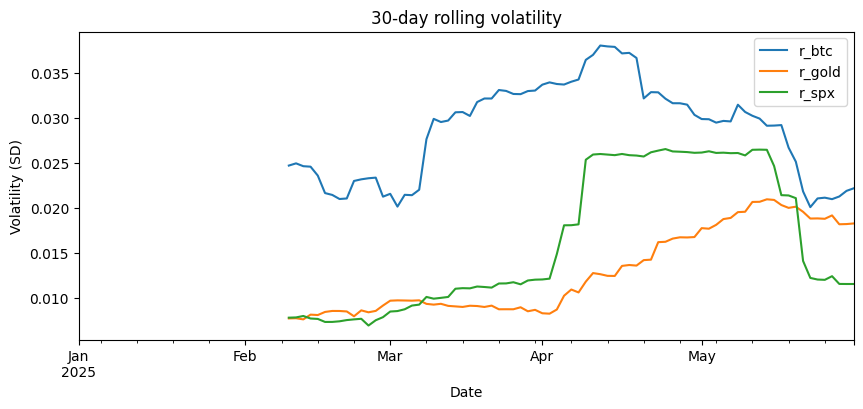

In [11]:

# Rolling 30-day volatility for selected assets
rolling_window = 30
vol = returns[["r_btc", "r_gold", "r_spx"]].rolling(rolling_window).std()

ax = vol.plot(title=f"{rolling_window}-day rolling volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility (SD)")
plt.show()


In [12]:

# Correlation matrix
corr = returns[["r_btc", "r_gold", "r_spx"]].corr()
corr


,r_btc,r_gold,r_spx
r_btc,1.0000,0.0504,0.3796
r_gold,0.0504,1.0000,-0.0177
r_spx,0.3796,-0.0177,1.0000



## 6. Stationarity checks (ADF tests)


In [13]:

def adf_test(series, name=""):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"ADF Test for {name}")
    print(f"  Test statistic: {result[0]:.4f}")
    print(f"  p-value:        {result[1]:.4f}")
    print("  Critical values:")
    for k, v in result[4].items():
        print(f"    {k}: {v:.4f}")
    print("-" * 40)

for col in returns.columns:
    adf_test(returns[col], name=col)


ADF Test for r_btc
  Test statistic: -11.3955
  p-value:        0.0000
  Critical values:
    1%: -3.4930
    5%: -2.8890
    10%: -2.5814
----------------------------------------
ADF Test for r_gold
  Test statistic: -10.2024
  p-value:        0.0000
  Critical values:
    1%: -3.4930
    5%: -2.8890
    10%: -2.5814
----------------------------------------
ADF Test for r_spx
  Test statistic: -11.3953
  p-value:        0.0000
  Critical values:
    1%: -3.4930
    5%: -2.8890
    10%: -2.5814
----------------------------------------
ADF Test for dln_eurusd
  Test statistic: -10.1000
  p-value:        0.0000
  Critical values:
    1%: -3.4930
    5%: -2.8890
    10%: -2.5814
----------------------------------------
ADF Test for dln_usdcny
  Test statistic: -10.4155
  p-value:        0.0000
  Critical values:
    1%: -3.4930
    5%: -2.8890
    10%: -2.5814
----------------------------------------
ADF Test for dln_oil
  Test statistic: -5.0250
  p-value:        0.0000
  Critical values


## 7. Baseline ARX models (no emotions)

We estimate an ARX model for each asset:

\[ r_{i,t} = \alpha + \sum_{k=1}^{p} \phi_k r_{i,t-k} + \beta' x_t + \varepsilon_t, \]

where \(x_t\) are the macro control variables.


In [14]:
# Prepare a working copy
# Build lags up to max_p to allow testing alternative AR orders
max_p = 3
p = 1  # baseline order used below

data = returns.copy()

# Create lags for each asset
for asset in ["r_btc", "r_gold", "r_spx"]:
    for lag in range(1, max_p + 1):
        data[f"{asset}_l{lag}"] = data[asset].shift(lag)

# Control variable names
control_cols = ["dln_eurusd", "dln_usdcny", "dln_oil", "dy10"]

data_arx = data.dropna()
data_arx.head()


,r_btc,r_gold,r_spx,dln_eurusd,dln_usdcny,dln_oil,dy10,ei_creator,ei_community,epi,...,epi_Conspiracy and Historical Events,r_btc_l1,r_btc_l2,r_btc_l3,r_gold_l1,r_gold_l2,r_gold_l3,r_spx_l1,r_spx_l2,r_spx_l3
2025-01-06,0.0397,-0.0025,0.0055,-0.0036,0.0029,-0.0054,0.0220,0.2727,0.0000,-0.3409,...,0.0000,0.0125,0.0258,0.0105,-0.0052,0.0112,0.0000,0.0125,-0.0022,0.0000
2025-01-07,-0.0518,0.0069,-0.0112,-0.0078,0.0004,0.0093,0.0650,0.6000,-0.1972,-0.9966,...,-1.0000,0.0397,0.0125,0.0258,-0.0025,-0.0052,0.0112,0.0055,0.0125,-0.0022
2025-01-08,-0.0196,0.0029,0.0016,0.0039,0.0006,-0.0126,0.0100,0.0000,-0.2396,-0.2995,...,-1.0000,-0.0518,0.0397,0.0125,0.0069,-0.0025,-0.0052,-0.0112,0.0055,0.0125
2025-01-09,-0.0273,0.0072,0.0000,0.0030,0.0007,0.0081,0.0000,0.0000,-0.3575,-0.4469,...,-1.0000,-0.0196,-0.0518,0.0397,0.0029,0.0069,-0.0025,0.0016,-0.0112,0.0055
2025-01-10,0.0237,0.0092,-0.0155,0.0017,0.0001,0.0352,0.0830,0.3333,-0.3713,-0.8808,...,0.0000,-0.0273,-0.0196,-0.0518,0.0072,0.0029,0.0069,0.0000,0.0016,-0.0112


In [15]:

def fit_arx(data, asset, p=1, control_cols=None):
    if control_cols is None:
        control_cols = []

    cols_lag = [f"{asset}_l{lag}" for lag in range(1, p + 1)]
    cols_exog = cols_lag + control_cols

    df = data.dropna(subset=[asset] + cols_exog)
    y = df[asset]
    X = sm.add_constant(df[cols_exog])

    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":5})
    return model

arx_results = {}
for asset in ["r_btc", "r_gold", "r_spx"]:
    model = fit_arx(data, asset, p=p, control_cols=control_cols)
    arx_results[asset] = model
    print(f"\n=== ARX results for {asset} ===")
    print(model.summary().tables[1])



=== ARX results for r_btc ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.002      0.336      0.737      -0.004       0.005
r_btc_l1      -0.0717      0.090     -0.795      0.427      -0.249       0.105
dln_eurusd    -0.9205      0.458     -2.010      0.044      -1.818      -0.023
dln_usdcny    -0.0249      0.753     -0.033      0.974      -1.500       1.450
dln_oil        0.2915      0.149      1.956      0.050      -0.001       0.584
dy10           0.0779      0.065      1.196      0.232      -0.050       0.206

=== ARX results for r_gold ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0023      0.001      2.256      0.024       0.000       0.004
r_gold_l1     -0.0445      0.133     -0.334      0.738      -0.305  

In [16]:
# Explore ARX lag lengths (p = 1..3)
lag_options = [1, 2, 3]
arx_metrics = []

for p_opt in lag_options:
    for asset in ["r_btc", "r_gold", "r_spx"]:
        model = fit_arx(data, asset, p=p_opt, control_cols=control_cols)
        arx_metrics.append({
            "asset": asset,
            "p": p_opt,
            "aic": model.aic,
            "bic": model.bic,
            "r2": model.rsquared,
            "nobs": model.nobs,
        })

arx_metrics_df = pd.DataFrame(arx_metrics)
print("ARX info criteria (lower is better):")
display(arx_metrics_df.pivot(index="asset", columns="p", values="bic").round(3))
display(arx_metrics_df.pivot(index="asset", columns="p", values="aic").round(3))
print("ARX R^2 by lag order:")
display(arx_metrics_df.pivot(index="asset", columns="p", values="r2").round(4))


ARX info criteria (lower is better):


p,1,2,3
asset,,,
r_btc,-447.8020,-438.6700,-429.8210
r_gold,-599.0270,-588.1050,-579.3050
r_spx,-582.6300,-571.9250,-561.1310


p,1,2,3
asset,,,
r_btc,-463.8390,-457.3140,-451.0530
r_gold,-615.0640,-606.7490,-600.5360
r_spx,-598.6670,-590.5690,-582.3620


ARX R^2 by lag order:


p,1,2,3
asset,,,
r_btc,0.1234,0.1244,0.1327
r_gold,0.0531,0.0537,0.0746
r_spx,0.2462,0.2503,0.2496


In [17]:
# ARX lag selection with rolling 1-step forecasts
p_grid = [1, 2, 3]
min_train = 60
assets = ["r_btc", "r_gold", "r_spx"]

sel_records = []
for asset in assets:
    for p_opt in p_grid:
        cols_lag = [f"{asset}_l{lag}" for lag in range(1, p_opt + 1)]
        cols_exog = cols_lag + control_cols
        df_fit = data.dropna(subset=[asset] + cols_exog)
        if df_fit.empty:
            continue
        y_all = df_fit[asset]
        X_all = sm.add_constant(df_fit[cols_exog], has_constant="add")

        full_model = sm.OLS(y_all, X_all).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

        if len(df_fit) <= min_train:
            mae = rmse = float("nan")
        else:
            preds, actuals, dates = [], [], []
            for i in range(min_train, len(df_fit)):
                y_train = y_all.iloc[:i]
                X_train = X_all.iloc[:i]
                m = sm.OLS(y_train, X_train).fit()
                x_next = sm.add_constant(df_fit[cols_exog].iloc[i:i+1], has_constant="add")
                pred = m.predict(x_next).iloc[0]
                preds.append(pred)
                actuals.append(y_all.iloc[i])
                dates.append(df_fit.index[i])
            err = pd.Series(preds, index=dates) - pd.Series(actuals, index=dates)
            mae = err.abs().mean()
            rmse = (err.pow(2).mean()) ** 0.5

        sel_records.append({
            "asset": asset,
            "p": p_opt,
            "aic": full_model.aic,
            "bic": full_model.bic,
            "mae": mae,
            "rmse": rmse,
            "nobs": len(df_fit),
        })

sel_df_arx = pd.DataFrame(sel_records)
print("ARX lag grid (lower is better):")
print(sel_df_arx.pivot(index="asset", columns="p", values="bic").round(3))
print(sel_df_arx.pivot(index="asset", columns="p", values="aic").round(3))
print("MAE (rolling 1-step):")
print(sel_df_arx.pivot(index="asset", columns="p", values="mae").round(5))
print("RMSE (rolling 1-step):")
print(sel_df_arx.pivot(index="asset", columns="p", values="rmse").round(5))

best_bic_arx = sel_df_arx.sort_values("bic").groupby("asset").first()
best_rmse_arx = sel_df_arx.sort_values("rmse").groupby("asset").first()
print("Best by BIC per asset:")
print(best_bic_arx[["bic", "p"]])
print("Best by RMSE per asset:")
print(best_rmse_arx[["rmse", "p"]])


ARX lag grid (lower is better):
p              1         2         3
asset                               
r_btc  -447.8020 -438.6700 -429.8210
r_gold -599.0270 -588.1050 -579.3050
r_spx  -582.6300 -571.9250 -561.1310
p              1         2         3
asset                               
r_btc  -463.8390 -457.3140 -451.0530
r_gold -615.0640 -606.7490 -600.5360
r_spx  -598.6670 -590.5690 -582.3620
MAE (rolling 1-step):
p           1      2      3
asset                      
r_btc  0.0201 0.0207 0.0203
r_gold 0.0150 0.0155 0.0155
r_spx  0.0141 0.0143 0.0151
RMSE (rolling 1-step):
p           1      2      3
asset                      
r_btc  0.0266 0.0271 0.0272
r_gold 0.0184 0.0188 0.0191
r_spx  0.0202 0.0204 0.0218
Best by BIC per asset:
             bic  p
asset              
r_btc  -447.8024  1
r_gold -599.0272  1
r_spx  -582.6299  1
Best by RMSE per asset:
         rmse  p
asset           
r_btc  0.0266  1
r_gold 0.0184  1
r_spx  0.0202  1


ARX r_btc: p=1, MAE=0.02010, RMSE=0.02658


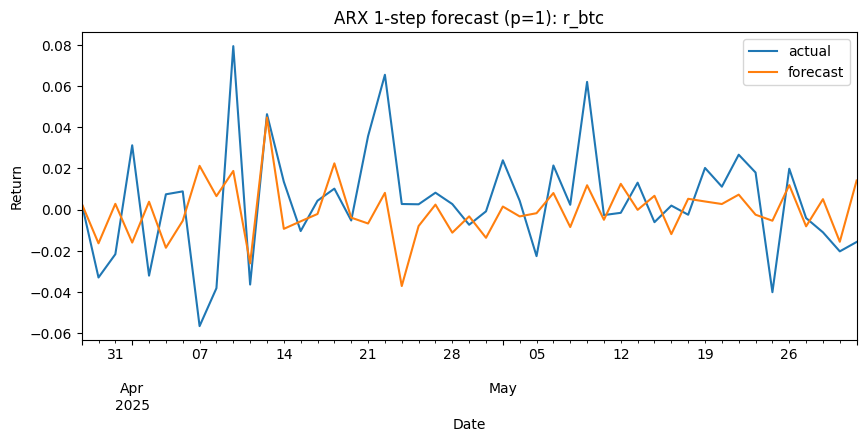

ARX r_gold: p=1, MAE=0.01504, RMSE=0.01837


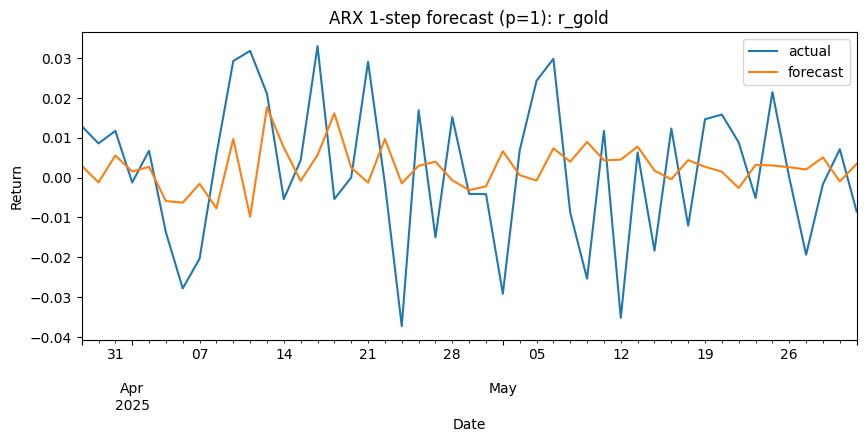

ARX r_spx: p=1, MAE=0.01407, RMSE=0.02019


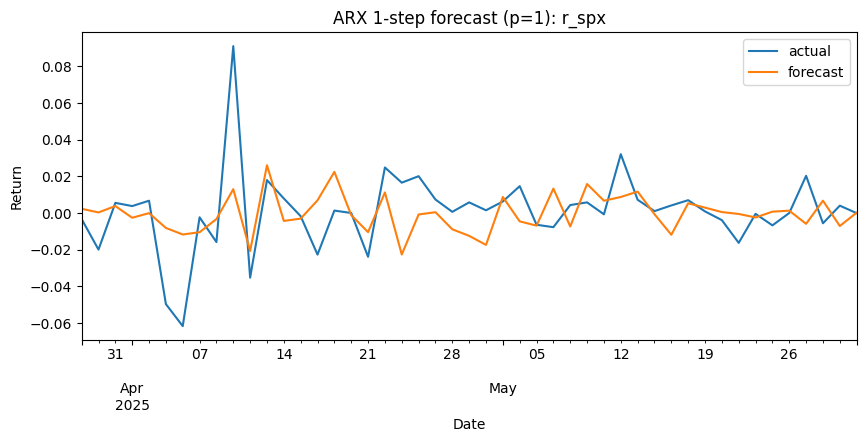

In [18]:
# Plot ARX forecasts using best lag (by RMSE)
min_train = 60
assets = ["r_btc", "r_gold", "r_spx"]

if 'best_rmse_arx' not in globals():
    raise RuntimeError("Run the ARX selection cell first.")

for asset in assets:
    p_opt = int(best_rmse_arx.loc[asset, 'p'])
    cols_lag = [f"{asset}_l{lag}" for lag in range(1, p_opt + 1)]
    cols_exog = cols_lag + control_cols
    df_fit = data.dropna(subset=[asset] + cols_exog)
    if len(df_fit) <= min_train:
        print(f"Not enough observations for {asset} with p={p_opt}")
        continue

    y_all = df_fit[asset]
    preds, dates = [], []
    for i in range(min_train, len(df_fit)):
        y_train = y_all.iloc[:i]
        X_train = sm.add_constant(df_fit[cols_exog].iloc[:i], has_constant="add")
        m = sm.OLS(y_train, X_train).fit()
        x_next = sm.add_constant(df_fit[cols_exog].iloc[i:i+1], has_constant="add")
        pred = m.predict(x_next).iloc[0]
        preds.append(pred)
        dates.append(df_fit.index[i])

    fc_series = pd.Series(preds, index=dates, name="forecast")
    actual_series = y_all.loc[fc_series.index]
    mae = (fc_series - actual_series).abs().mean()
    rmse = ((fc_series - actual_series) ** 2).mean() ** 0.5
    print(f"ARX {asset}: p={p_opt}, MAE={mae:.5f}, RMSE={rmse:.5f}")

    ax = actual_series.plot(label="actual", title=f"ARX 1-step forecast (p={p_opt}): {asset}")
    fc_series.plot(ax=ax, label="forecast")
    ax.legend()
    ax.set_xlabel("Date")
    ax.set_ylabel("Return")
    plt.show()


## 7b. ARX models with EPI

We augment the baseline ARX model by adding the Emotion Polarity Index (EPI) as an additional exogenous regressor:

\[ r_{i,t} = \alpha + \sum_{k=1}^{p} \phi_k r_{i,t-k} + \beta' x_t + \gamma \cdot \text{EPI}_t + \varepsilon_t \]

In [19]:
# ARX with EPI - lag selection using rolling 1-step forecasts
p_grid = [1, 2, 3]
min_train = 60
assets = ["r_btc", "r_gold", "r_spx"]

# Control columns now include EPI
control_cols_epi = control_cols + ["epi"]

sel_records_epi = []
for asset in assets:
    for p_opt in p_grid:
        cols_lag = [f"{asset}_l{lag}" for lag in range(1, p_opt + 1)]
        cols_exog = cols_lag + control_cols_epi
        df_fit = data.dropna(subset=[asset] + cols_exog)
        if df_fit.empty:
            continue
        y_all = df_fit[asset]
        X_all = sm.add_constant(df_fit[cols_exog], has_constant="add")

        full_model = sm.OLS(y_all, X_all).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

        if len(df_fit) <= min_train:
            mae = rmse = float("nan")
        else:
            preds, actuals, dates = [], [], []
            for i in range(min_train, len(df_fit)):
                y_train = y_all.iloc[:i]
                X_train = X_all.iloc[:i]
                m = sm.OLS(y_train, X_train).fit()
                x_next = sm.add_constant(df_fit[cols_exog].iloc[i:i+1], has_constant="add")
                pred = m.predict(x_next).iloc[0]
                preds.append(pred)
                actuals.append(y_all.iloc[i])
                dates.append(df_fit.index[i])
            err = pd.Series(preds, index=dates) - pd.Series(actuals, index=dates)
            mae = err.abs().mean()
            rmse = (err.pow(2).mean()) ** 0.5

        sel_records_epi.append({
            "asset": asset,
            "p": p_opt,
            "aic": full_model.aic,
            "bic": full_model.bic,
            "mae": mae,
            "rmse": rmse,
            "nobs": len(df_fit),
            "model": "ARX + EPI"
        })

sel_df_arx_epi = pd.DataFrame(sel_records_epi)
print("ARX + EPI lag grid (lower is better):")
print(sel_df_arx_epi.pivot(index="asset", columns="p", values="bic").round(3))
print("MAE (rolling 1-step):")
print(sel_df_arx_epi.pivot(index="asset", columns="p", values="mae").round(5))
print("RMSE (rolling 1-step):")
print(sel_df_arx_epi.pivot(index="asset", columns="p", values="rmse").round(5))

best_bic_arx_epi = sel_df_arx_epi.sort_values("bic").groupby("asset").first()
best_rmse_arx_epi = sel_df_arx_epi.sort_values("rmse").groupby("asset").first()
print("\nBest by BIC per asset:")
print(best_bic_arx_epi[["bic", "p"]])
print("Best by RMSE per asset:")
print(best_rmse_arx_epi[["rmse", "p"]])

ARX + EPI lag grid (lower is better):
p              1         2         3
asset                               
r_btc  -443.1740 -434.2260 -425.2530
r_gold -594.7150 -584.0460 -575.3150
r_spx  -587.4410 -576.4000 -565.5380
MAE (rolling 1-step):
p           1      2      3
asset                      
r_btc  0.0200 0.0205 0.0202
r_gold 0.0153 0.0157 0.0157
r_spx  0.0134 0.0136 0.0146
RMSE (rolling 1-step):
p           1      2      3
asset                      
r_btc  0.0268 0.0272 0.0273
r_gold 0.0186 0.0190 0.0192
r_spx  0.0193 0.0196 0.0209

Best by BIC per asset:
             bic  p
asset              
r_btc  -443.1742  1
r_gold -594.7154  1
r_spx  -587.4414  1
Best by RMSE per asset:
         rmse  p
asset           
r_btc  0.0268  1
r_gold 0.0186  1
r_spx  0.0193  1


## 7c. ARX models with Topic-Weighted EPI

We augment the ARX model using the topic-weighted EPI (`epi_weighted`) which accounts for the relative importance of different topics:

\[ r_{i,t} = \alpha + \sum_{k=1}^{p} \phi_k r_{i,t-k} + \beta' x_t + \gamma \cdot \text{EPI}^{weighted}_t + \varepsilon_t \]

In [20]:
# ARX with Topic-Weighted EPI - lag selection using rolling 1-step forecasts
p_grid = [1, 2, 3]
min_train = 60
assets = ["r_btc", "r_gold", "r_spx"]

# Control columns now include topic-weighted EPI
control_cols_epi_weighted = control_cols + ["epi_weighted"]

sel_records_epi_weighted = []
for asset in assets:
    for p_opt in p_grid:
        cols_lag = [f"{asset}_l{lag}" for lag in range(1, p_opt + 1)]
        cols_exog = cols_lag + control_cols_epi_weighted
        df_fit = data.dropna(subset=[asset] + cols_exog)
        if df_fit.empty:
            continue
        y_all = df_fit[asset]
        X_all = sm.add_constant(df_fit[cols_exog], has_constant="add")

        full_model = sm.OLS(y_all, X_all).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

        if len(df_fit) <= min_train:
            mae = rmse = float("nan")
        else:
            preds, actuals, dates = [], [], []
            for i in range(min_train, len(df_fit)):
                y_train = y_all.iloc[:i]
                X_train = X_all.iloc[:i]
                m = sm.OLS(y_train, X_train).fit()
                x_next = sm.add_constant(df_fit[cols_exog].iloc[i:i+1], has_constant="add")
                pred = m.predict(x_next).iloc[0]
                preds.append(pred)
                actuals.append(y_all.iloc[i])
                dates.append(df_fit.index[i])
            err = pd.Series(preds, index=dates) - pd.Series(actuals, index=dates)
            mae = err.abs().mean()
            rmse = (err.pow(2).mean()) ** 0.5

        sel_records_epi_weighted.append({
            "asset": asset,
            "p": p_opt,
            "aic": full_model.aic,
            "bic": full_model.bic,
            "mae": mae,
            "rmse": rmse,
            "nobs": len(df_fit),
            "model": "ARX + EPI_weighted"
        })

sel_df_arx_epi_weighted = pd.DataFrame(sel_records_epi_weighted)
print("ARX + Topic-Weighted EPI lag grid (lower is better):")
print(sel_df_arx_epi_weighted.pivot(index="asset", columns="p", values="bic").round(3))
print("MAE (rolling 1-step):")
print(sel_df_arx_epi_weighted.pivot(index="asset", columns="p", values="mae").round(5))
print("RMSE (rolling 1-step):")
print(sel_df_arx_epi_weighted.pivot(index="asset", columns="p", values="rmse").round(5))

best_bic_arx_epi_weighted = sel_df_arx_epi_weighted.sort_values("bic").groupby("asset").first()
best_rmse_arx_epi_weighted = sel_df_arx_epi_weighted.sort_values("rmse").groupby("asset").first()
print("\nBest by BIC per asset:")
print(best_bic_arx_epi_weighted[["bic", "p"]])
print("Best by RMSE per asset:")
print(best_rmse_arx_epi_weighted[["rmse", "p"]])

ARX + Topic-Weighted EPI lag grid (lower is better):
p              1         2         3
asset                               
r_btc  -443.1320 -434.0250 -425.1680
r_gold -594.5060 -583.6560 -574.8940
r_spx  -577.9640 -567.2620 -556.4880
MAE (rolling 1-step):
p           1      2      3
asset                      
r_btc  0.0202 0.0208 0.0205
r_gold 0.0151 0.0156 0.0157
r_spx  0.0142 0.0144 0.0153
RMSE (rolling 1-step):
p           1      2      3
asset                      
r_btc  0.0267 0.0272 0.0273
r_gold 0.0185 0.0190 0.0192
r_spx  0.0204 0.0206 0.0220

Best by BIC per asset:
             bic  p
asset              
r_btc  -443.1322  1
r_gold -594.5060  1
r_spx  -577.9644  1
Best by RMSE per asset:
         rmse  p
asset           
r_btc  0.0267  1
r_gold 0.0185  1
r_spx  0.0204  1



## 8. Baseline VAR model (no emotions)

We estimate a VAR model on the three return series, optionally with exogenous macro controls.


In [21]:
# VAR with exogenous controls
Y = returns[["r_btc", "r_gold", "r_spx"]]
X_exog = returns[control_cols]

# Align and drop missing rows
var_data = pd.concat([Y, X_exog], axis=1).dropna()
Y_var = var_data[["r_btc", "r_gold", "r_spx"]]
X_var = var_data[control_cols]

# Select lag order (can inspect select_order results)
var_model = VAR(Y_var, exog=X_var)
lag_order_results = var_model.select_order(maxlags=10)
print(lag_order_results.summary())


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0      -24.31*     -23.91*  2.773e-11*     -24.15*
1       -24.20      -23.57   3.094e-11      -23.94
2       -24.12      -23.25   3.345e-11      -23.77
3       -24.12      -23.01   3.365e-11      -23.67
4       -24.09      -22.74   3.502e-11      -23.54
5       -24.04      -22.46   3.691e-11      -23.40
6       -23.97      -22.15   3.994e-11      -23.23
7       -23.85      -21.79   4.571e-11      -23.02
8       -23.73      -21.43   5.228e-11      -22.80
9       -23.83      -21.29   4.844e-11      -22.80
10      -23.86      -21.09   4.777e-11      -22.74
--------------------------------------------------


In [22]:
# Fit VAR with chosen lag order (e.g. 1)
p_var = 1
var_model = VAR(Y_var, exog=X_var)
var_results = var_model.fit(p_var, trend="c")

print(var_results.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 13, Dec, 2025
Time:                     17:09:19
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -23.6713
Nobs:                     107.000    HQIC:                  -24.0277
Log likelihood:           867.007    FPE:                2.88207e-11
AIC:                     -24.2708    Det(Omega_mle):     2.32146e-11
--------------------------------------------------------------------
Results for equation r_btc
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const              0.000409         0.002670            0.153           0.878
dln_eurusd        -0.693533         0.495833           -1.399           0.162
dln_usdcny        -0.105881         1.101340           -0.096           

In [23]:
# Compare VAR lag lengths with exogenous controls (p = 1..3)
var_compare = []
var_results_by_p = {}
for p_opt in [1, 2, 3]:
    res = VAR(Y_var, exog=X_var).fit(p_opt, trend="c")
    var_results_by_p[p_opt] = res
    var_compare.append({
        "p": p_opt,
        "aic": res.aic,
        "bic": res.bic,
        "hqic": res.hqic,
        "fpe": res.fpe,
    })

var_compare_df = pd.DataFrame(var_compare).set_index("p")
print("VAR info criteria (lower is better):")
print(var_compare_df.round(4))

from statsmodels.stats.stattools import durbin_watson
for p_opt, res in var_results_by_p.items():
    dw = durbin_watson(res.resid)
    print(f"Durbin-Watson (p={p_opt}): BTC {dw[0]:.2f}, Gold {dw[1]:.2f}, SPX {dw[2]:.2f}")


VAR info criteria (lower is better):
       aic      bic     hqic    fpe
p                                  
1 -24.2708 -23.6713 -24.0277 0.0000
2 -24.1795 -23.3504 -23.8435 0.0000
3 -24.1566 -23.0950 -23.7264 0.0000
Durbin-Watson (p=1): BTC 2.04, Gold 1.96, SPX 2.06
Durbin-Watson (p=2): BTC 2.02, Gold 1.87, SPX 2.05
Durbin-Watson (p=3): BTC 2.00, Gold 1.98, SPX 2.18


### Predictions

In [25]:
# Model selection over lag choices using rolling 1-step forecasts (VAR)
# Loops over p in p_grid, reports BIC/AIC and rolling MAE/RMSE, and picks the best by RMSE
p_grid = [1, 2, 3]
min_train = 60

try:
    Y_base = Y_var.copy()
    X_base = X_var.copy()
except NameError:
    raise RuntimeError("Run the VAR setup cells before this selection cell.")

sel_records_var = []
for p_opt in p_grid:
    res = VAR(Y_base, exog=X_base).fit(p_opt, trend="c")
    if len(Y_base) <= min_train + p_opt:
        mae = rmse = {"r_btc": float("nan"), "r_gold": float("nan"), "r_spx": float("nan"), "avg": float("nan")}
    else:
        preds = []
        dates = Y_base.index[min_train:]
        for i, dt in enumerate(dates):
            train_end = min_train + i
            y_train = Y_base.iloc[:train_end]
            x_train = X_base.iloc[:train_end]
            model = VAR(y_train, exog=x_train).fit(p_opt, trend="c")
            y_last = y_train.values[-model.k_ar:]
            x_future = X_base.iloc[train_end:train_end+1].values
            pred = model.forecast(y_last, steps=1, exog_future=x_future)[0]
            preds.append({"date": dt, "pred_r_btc": pred[0], "pred_r_gold": pred[1], "pred_r_spx": pred[2]})
        fc_df = pd.DataFrame(preds).set_index("date")
        actual = Y_base.loc[fc_df.index]
        diff = fc_df.to_numpy() - actual.to_numpy()
        mae_vec = np.abs(diff).mean(axis=0)
        rmse_vec = np.sqrt((diff ** 2).mean(axis=0))
        mae = {"r_btc": mae_vec[0], "r_gold": mae_vec[1], "r_spx": mae_vec[2], "avg": mae_vec.mean()}
        rmse = {"r_btc": rmse_vec[0], "r_gold": rmse_vec[1], "r_spx": rmse_vec[2], "avg": rmse_vec.mean()}

    sel_records_var.append({
        "p": p_opt,
        "bic": res.bic,
        "aic": res.aic,
        "mae_btc": mae["r_btc"], "mae_gold": mae["r_gold"], "mae_spx": mae["r_spx"], "mae_avg": mae["avg"],
        "rmse_btc": rmse["r_btc"], "rmse_gold": rmse["r_gold"], "rmse_spx": rmse["r_spx"], "rmse_avg": rmse["avg"],
    })

sel_df_var = pd.DataFrame(sel_records_var).set_index("p")
print("Lag grid results (lower is better):")
print(sel_df_var[["bic", "aic", "mae_avg", "rmse_avg"]].round(4))

best_bic_p_var = sel_df_var["bic"].idxmin()
best_rmse_p_var = sel_df_var["rmse_avg"].idxmin()
print(f"Best by BIC: p={best_bic_p_var}")
print(f"Best by avg RMSE: p={best_rmse_p_var}")


Lag grid results (lower is better):
       bic      aic  mae_avg  rmse_avg
p                                     
1 -23.6713 -24.2708   0.0170    0.0221
2 -23.3504 -24.1795   0.0169    0.0223
3 -23.0950 -24.1566   0.0176    0.0230
Best by BIC: p=1
Best by avg RMSE: p=1


Rolling 1-step forecast metrics (VAR p=1):
               mae   rmse
pred_r_btc  0.0219 0.0219
pred_r_gold 0.0145 0.0145
pred_r_spx  0.0147 0.0147


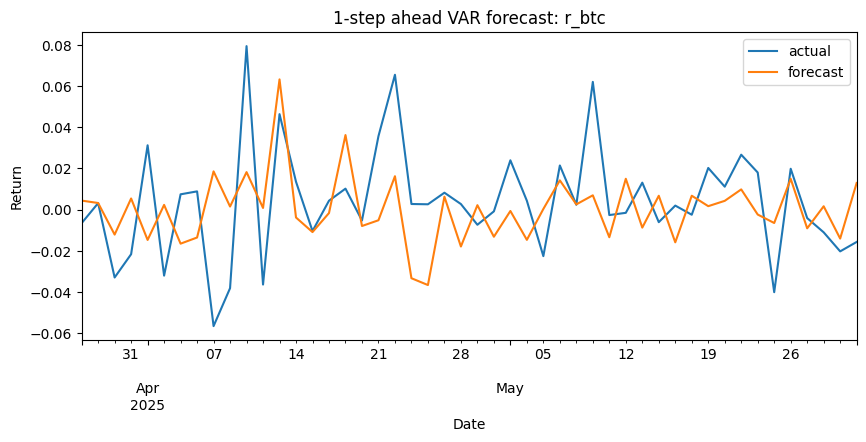

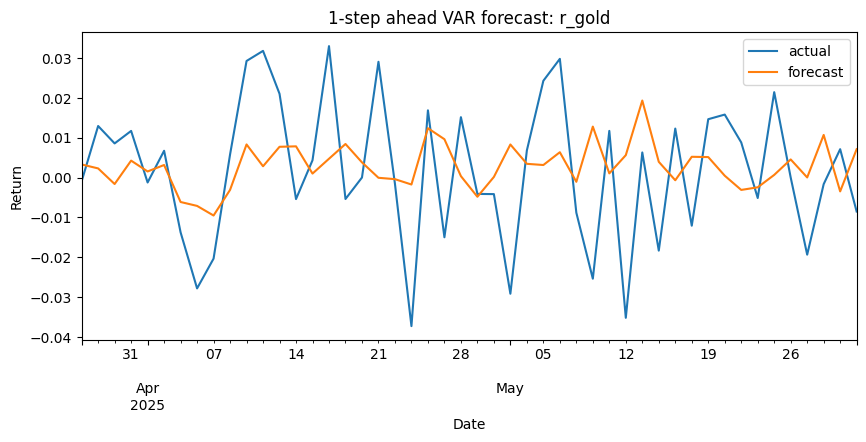

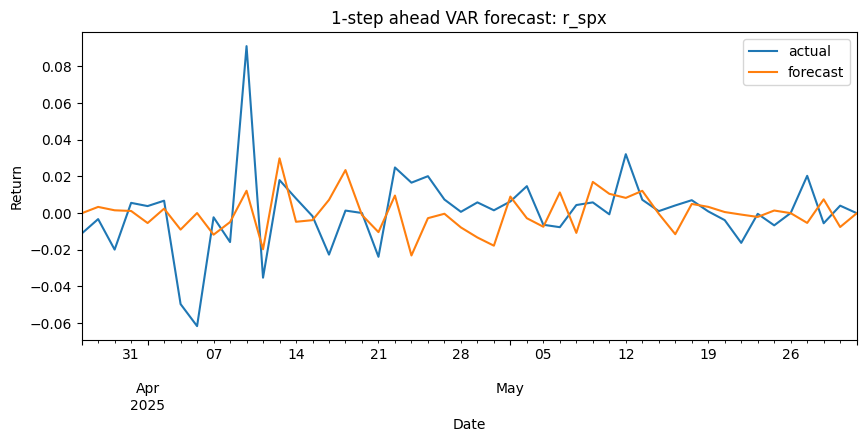

In [26]:
# Rolling one-step-ahead forecasts (VAR with exogenous controls)
# Uses expanding window, 1-step ahead, p=1 by default
p_forecast = best_rmse_p_var if "best_rmse_p_var" in globals() else 2
min_train = 60  # need enough history for stable estimates

# Reuse prepared Y_var and X_var; ensure they exist
try:
    Y_base = Y_var.copy()
    X_base = X_var.copy()
except NameError:
    raise RuntimeError("Ensure VAR setup cells have been run before this forecast cell.")

if len(Y_base) <= min_train + p_forecast:
    print("Not enough observations for rolling forecasts")
else:
    records = []
    dates = Y_base.index[min_train:]
    for i, dt in enumerate(dates):
        train_end = min_train + i
        y_train = Y_base.iloc[:train_end]
        x_train = X_base.iloc[:train_end]
        model = VAR(y_train, exog=x_train).fit(p_forecast, trend="c")
        y_last = y_train.values[-model.k_ar:]
        x_future = X_base.iloc[train_end:train_end+1].values
        pred = model.forecast(y_last, steps=1, exog_future=x_future)[0]
        records.append({
            "date": dt,
            "pred_r_btc": pred[0],
            "pred_r_gold": pred[1],
            "pred_r_spx": pred[2],
        })
    fc_df = pd.DataFrame(records).set_index("date")
    actual = Y_base.loc[fc_df.index]
    eval_df = pd.DataFrame({
        "mae": (fc_df.sub(actual.values)).abs().mean(),
        "rmse": np.sqrt((fc_df.sub(actual.values))**2).mean(),
    })
    print(f"Rolling 1-step forecast metrics (VAR p={p_forecast}):")
    print(eval_df)

    # Plot actual vs predicted
    for col, pred_col in [("r_btc", "pred_r_btc"), ("r_gold", "pred_r_gold"), ("r_spx", "pred_r_spx")]:
        ax = actual[col].plot(label="actual", title=f"1-step ahead VAR forecast: {col}")
        fc_df[pred_col].plot(ax=ax, label="forecast")
        ax.legend()
        ax.set_xlabel("Date")
        ax.set_ylabel("Return")
        plt.show()


## 8b. VAR model with EPI

We extend the baseline VAR by adding the EPI as an additional exogenous variable alongside the macro controls.

In [27]:
# VAR with EPI as exogenous variable
Y_var_epi = returns[["r_btc", "r_gold", "r_spx"]]
X_var_epi = returns[control_cols + ["epi"]]

# Align and drop missing rows
var_data_epi = pd.concat([Y_var_epi, X_var_epi], axis=1).dropna()
Y_var_epi = var_data_epi[["r_btc", "r_gold", "r_spx"]]
X_var_epi = var_data_epi[control_cols + ["epi"]]

# Model selection with rolling 1-step forecasts
p_grid = [1, 2, 3]
min_train = 60

sel_records_var_epi = []
for p_opt in p_grid:
    res = VAR(Y_var_epi, exog=X_var_epi).fit(p_opt, trend="c")
    if len(Y_var_epi) <= min_train + p_opt:
        mae = rmse = {"r_btc": float("nan"), "r_gold": float("nan"), "r_spx": float("nan"), "avg": float("nan")}
    else:
        preds = []
        dates = Y_var_epi.index[min_train:]
        for i, dt in enumerate(dates):
            train_end = min_train + i
            y_train = Y_var_epi.iloc[:train_end]
            x_train = X_var_epi.iloc[:train_end]
            model = VAR(y_train, exog=x_train).fit(p_opt, trend="c")
            y_last = y_train.values[-model.k_ar:]
            x_future = X_var_epi.iloc[train_end:train_end+1].values
            pred = model.forecast(y_last, steps=1, exog_future=x_future)[0]
            preds.append({"date": dt, "pred_r_btc": pred[0], "pred_r_gold": pred[1], "pred_r_spx": pred[2]})
        fc_df = pd.DataFrame(preds).set_index("date")
        actual = Y_var_epi.loc[fc_df.index]
        diff = fc_df.to_numpy() - actual.to_numpy()
        mae_vec = np.abs(diff).mean(axis=0)
        rmse_vec = np.sqrt((diff ** 2).mean(axis=0))
        mae = {"r_btc": mae_vec[0], "r_gold": mae_vec[1], "r_spx": mae_vec[2], "avg": mae_vec.mean()}
        rmse = {"r_btc": rmse_vec[0], "r_gold": rmse_vec[1], "r_spx": rmse_vec[2], "avg": rmse_vec.mean()}

    sel_records_var_epi.append({
        "p": p_opt,
        "bic": res.bic,
        "aic": res.aic,
        "mae_btc": mae["r_btc"], "mae_gold": mae["r_gold"], "mae_spx": mae["r_spx"], "mae_avg": mae["avg"],
        "rmse_btc": rmse["r_btc"], "rmse_gold": rmse["r_gold"], "rmse_spx": rmse["r_spx"], "rmse_avg": rmse["avg"],
        "model": "VAR + EPI"
    })

sel_df_var_epi = pd.DataFrame(sel_records_var_epi).set_index("p")
print("VAR + EPI lag grid results (lower is better):")
print(sel_df_var_epi[["bic", "aic", "mae_avg", "rmse_avg"]].round(4))

best_bic_p_var_epi = sel_df_var_epi["bic"].idxmin()
best_rmse_p_var_epi = sel_df_var_epi["rmse_avg"].idxmin()
print(f"\nBest by BIC: p={best_bic_p_var_epi}")
print(f"Best by avg RMSE: p={best_rmse_p_var_epi}")

VAR + EPI lag grid results (lower is better):
       bic      aic  mae_avg  rmse_avg
p                                     
1 -23.6488 -24.3232   0.0169    0.0219
2 -23.3251 -24.2296   0.0167    0.0221
3 -23.0697 -24.2071   0.0175    0.0229

Best by BIC: p=1
Best by avg RMSE: p=1


## 8c. VAR model with Topic-Weighted EPI

We extend the VAR model using the topic-weighted EPI (`epi_weighted`) as an exogenous variable.

In [28]:
# VAR with Topic-Weighted EPI as exogenous variable
Y_var_epi_w = returns[["r_btc", "r_gold", "r_spx"]]
X_var_epi_w = returns[control_cols + ["epi_weighted"]]

# Align and drop missing rows
var_data_epi_w = pd.concat([Y_var_epi_w, X_var_epi_w], axis=1).dropna()
Y_var_epi_w = var_data_epi_w[["r_btc", "r_gold", "r_spx"]]
X_var_epi_w = var_data_epi_w[control_cols + ["epi_weighted"]]

# Model selection with rolling 1-step forecasts
p_grid = [1, 2, 3]
min_train = 60

sel_records_var_epi_w = []
for p_opt in p_grid:
    res = VAR(Y_var_epi_w, exog=X_var_epi_w).fit(p_opt, trend="c")
    if len(Y_var_epi_w) <= min_train + p_opt:
        mae = rmse = {"r_btc": float("nan"), "r_gold": float("nan"), "r_spx": float("nan"), "avg": float("nan")}
    else:
        preds = []
        dates = Y_var_epi_w.index[min_train:]
        for i, dt in enumerate(dates):
            train_end = min_train + i
            y_train = Y_var_epi_w.iloc[:train_end]
            x_train = X_var_epi_w.iloc[:train_end]
            model = VAR(y_train, exog=x_train).fit(p_opt, trend="c")
            y_last = y_train.values[-model.k_ar:]
            x_future = X_var_epi_w.iloc[train_end:train_end+1].values
            pred = model.forecast(y_last, steps=1, exog_future=x_future)[0]
            preds.append({"date": dt, "pred_r_btc": pred[0], "pred_r_gold": pred[1], "pred_r_spx": pred[2]})
        fc_df = pd.DataFrame(preds).set_index("date")
        actual = Y_var_epi_w.loc[fc_df.index]
        diff = fc_df.to_numpy() - actual.to_numpy()
        mae_vec = np.abs(diff).mean(axis=0)
        rmse_vec = np.sqrt((diff ** 2).mean(axis=0))
        mae = {"r_btc": mae_vec[0], "r_gold": mae_vec[1], "r_spx": mae_vec[2], "avg": mae_vec.mean()}
        rmse = {"r_btc": rmse_vec[0], "r_gold": rmse_vec[1], "r_spx": rmse_vec[2], "avg": rmse_vec.mean()}

    sel_records_var_epi_w.append({
        "p": p_opt,
        "bic": res.bic,
        "aic": res.aic,
        "mae_btc": mae["r_btc"], "mae_gold": mae["r_gold"], "mae_spx": mae["r_spx"], "mae_avg": mae["avg"],
        "rmse_btc": rmse["r_btc"], "rmse_gold": rmse["r_gold"], "rmse_spx": rmse["r_spx"], "rmse_avg": rmse["avg"],
        "model": "VAR + EPI_weighted"
    })

sel_df_var_epi_w = pd.DataFrame(sel_records_var_epi_w).set_index("p")
print("VAR + Topic-Weighted EPI lag grid results (lower is better):")
print(sel_df_var_epi_w[["bic", "aic", "mae_avg", "rmse_avg"]].round(4))

best_bic_p_var_epi_w = sel_df_var_epi_w["bic"].idxmin()
best_rmse_p_var_epi_w = sel_df_var_epi_w["rmse_avg"].idxmin()
print(f"\nBest by BIC: p={best_bic_p_var_epi_w}")
print(f"Best by avg RMSE: p={best_rmse_p_var_epi_w}")

VAR + Topic-Weighted EPI lag grid results (lower is better):
       bic      aic  mae_avg  rmse_avg
p                                     
1 -23.5424 -24.2168   0.0172    0.0222
2 -23.2221 -24.1266   0.0170    0.0225
3 -22.9663 -24.1037   0.0177    0.0232

Best by BIC: p=1
Best by avg RMSE: p=1


## Model Comparison Summary

Compare the performance of all models: Baseline (no EPI), EPI, and Topic-Weighted EPI for both ARX and VAR specifications.

In [29]:
# ============================================================
# ARX Model Comparison: Baseline vs EPI vs Topic-Weighted EPI
# ============================================================

# Combine all ARX results
arx_comparison = []

# Baseline ARX (best by RMSE for each asset)
for asset in ["r_btc", "r_gold", "r_spx"]:
    best_row = sel_df_arx[sel_df_arx["asset"] == asset].sort_values("rmse").iloc[0]
    arx_comparison.append({
        "model": "ARX Baseline",
        "asset": asset,
        "p": int(best_row["p"]),
        "bic": best_row["bic"],
        "aic": best_row["aic"],
        "mae": best_row["mae"],
        "rmse": best_row["rmse"]
    })

# ARX + EPI (best by RMSE for each asset)
for asset in ["r_btc", "r_gold", "r_spx"]:
    best_row = sel_df_arx_epi[sel_df_arx_epi["asset"] == asset].sort_values("rmse").iloc[0]
    arx_comparison.append({
        "model": "ARX + EPI",
        "asset": asset,
        "p": int(best_row["p"]),
        "bic": best_row["bic"],
        "aic": best_row["aic"],
        "mae": best_row["mae"],
        "rmse": best_row["rmse"]
    })

# ARX + Topic-Weighted EPI (best by RMSE for each asset)
for asset in ["r_btc", "r_gold", "r_spx"]:
    best_row = sel_df_arx_epi_weighted[sel_df_arx_epi_weighted["asset"] == asset].sort_values("rmse").iloc[0]
    arx_comparison.append({
        "model": "ARX + EPI_weighted",
        "asset": asset,
        "p": int(best_row["p"]),
        "bic": best_row["bic"],
        "aic": best_row["aic"],
        "mae": best_row["mae"],
        "rmse": best_row["rmse"]
    })

arx_comparison_df = pd.DataFrame(arx_comparison)

print("=" * 70)
print("ARX Model Comparison (Best lag order by RMSE)")
print("=" * 70)
print("\nBy Asset and Model:")
display(arx_comparison_df.pivot_table(
    index="asset", 
    columns="model", 
    values=["rmse", "mae", "bic"],
    aggfunc="first"
).round(5))

# Calculate improvement percentages
print("\n" + "=" * 70)
print("RMSE Improvement over Baseline (%)")
print("=" * 70)
for asset in ["r_btc", "r_gold", "r_spx"]:
    baseline_rmse = arx_comparison_df[(arx_comparison_df["asset"] == asset) & 
                                       (arx_comparison_df["model"] == "ARX Baseline")]["rmse"].values[0]
    epi_rmse = arx_comparison_df[(arx_comparison_df["asset"] == asset) & 
                                  (arx_comparison_df["model"] == "ARX + EPI")]["rmse"].values[0]
    epi_w_rmse = arx_comparison_df[(arx_comparison_df["asset"] == asset) & 
                                    (arx_comparison_df["model"] == "ARX + EPI_weighted")]["rmse"].values[0]
    
    epi_improvement = (baseline_rmse - epi_rmse) / baseline_rmse * 100
    epi_w_improvement = (baseline_rmse - epi_w_rmse) / baseline_rmse * 100
    
    print(f"{asset}: EPI = {epi_improvement:+.2f}%, EPI_weighted = {epi_w_improvement:+.2f}%")

ARX Model Comparison (Best lag order by RMSE)

By Asset and Model:


bic                                       mae                     \
model  ARX + EPI ARX + EPI_weighted ARX Baseline ARX + EPI ARX + EPI_weighted   
asset                                                                           
r_btc  -443.1742          -443.1322    -447.8024    0.0200             0.0202   
r_gold -594.7153          -594.5060    -599.0272    0.0153             0.0151   
r_spx  -587.4414          -577.9644    -582.6299    0.0134             0.0142   

                         rmse                                  
model  ARX Baseline ARX + EPI ARX + EPI_weighted ARX Baseline  
asset                                                          
r_btc        0.0201    0.0268             0.0267       0.0266  
r_gold       0.0150    0.0186             0.0185       0.0184  
r_spx        0.0141    0.0193             0.0204       0.0202


RMSE Improvement over Baseline (%)
r_btc: EPI = -0.71%, EPI_weighted = -0.36%
r_gold: EPI = -1.14%, EPI_weighted = -0.45%
r_spx: EPI = +4.30%, EPI_weighted = -0.80%


In [30]:
# ============================================================
# VAR Model Comparison: Baseline vs EPI vs Topic-Weighted EPI
# ============================================================

# Combine all VAR results (best by RMSE)
var_comparison = []

# Baseline VAR
best_p_baseline = sel_df_var["rmse_avg"].idxmin()
var_comparison.append({
    "model": "VAR Baseline",
    "p": best_p_baseline,
    "bic": sel_df_var.loc[best_p_baseline, "bic"],
    "aic": sel_df_var.loc[best_p_baseline, "aic"],
    "rmse_btc": sel_df_var.loc[best_p_baseline, "rmse_btc"],
    "rmse_gold": sel_df_var.loc[best_p_baseline, "rmse_gold"],
    "rmse_spx": sel_df_var.loc[best_p_baseline, "rmse_spx"],
    "rmse_avg": sel_df_var.loc[best_p_baseline, "rmse_avg"],
    "mae_avg": sel_df_var.loc[best_p_baseline, "mae_avg"]
})

# VAR + EPI
best_p_epi = sel_df_var_epi["rmse_avg"].idxmin()
var_comparison.append({
    "model": "VAR + EPI",
    "p": best_p_epi,
    "bic": sel_df_var_epi.loc[best_p_epi, "bic"],
    "aic": sel_df_var_epi.loc[best_p_epi, "aic"],
    "rmse_btc": sel_df_var_epi.loc[best_p_epi, "rmse_btc"],
    "rmse_gold": sel_df_var_epi.loc[best_p_epi, "rmse_gold"],
    "rmse_spx": sel_df_var_epi.loc[best_p_epi, "rmse_spx"],
    "rmse_avg": sel_df_var_epi.loc[best_p_epi, "rmse_avg"],
    "mae_avg": sel_df_var_epi.loc[best_p_epi, "mae_avg"]
})

# VAR + Topic-Weighted EPI
best_p_epi_w = sel_df_var_epi_w["rmse_avg"].idxmin()
var_comparison.append({
    "model": "VAR + EPI_weighted",
    "p": best_p_epi_w,
    "bic": sel_df_var_epi_w.loc[best_p_epi_w, "bic"],
    "aic": sel_df_var_epi_w.loc[best_p_epi_w, "aic"],
    "rmse_btc": sel_df_var_epi_w.loc[best_p_epi_w, "rmse_btc"],
    "rmse_gold": sel_df_var_epi_w.loc[best_p_epi_w, "rmse_gold"],
    "rmse_spx": sel_df_var_epi_w.loc[best_p_epi_w, "rmse_spx"],
    "rmse_avg": sel_df_var_epi_w.loc[best_p_epi_w, "rmse_avg"],
    "mae_avg": sel_df_var_epi_w.loc[best_p_epi_w, "mae_avg"]
})

var_comparison_df = pd.DataFrame(var_comparison).set_index("model")

print("=" * 70)
print("VAR Model Comparison (Best lag order by avg RMSE)")
print("=" * 70)
display(var_comparison_df.round(5))

# Calculate improvement percentages
baseline_rmse = var_comparison_df.loc["VAR Baseline", "rmse_avg"]
epi_rmse = var_comparison_df.loc["VAR + EPI", "rmse_avg"]
epi_w_rmse = var_comparison_df.loc["VAR + EPI_weighted", "rmse_avg"]

print("\n" + "=" * 70)
print("VAR RMSE Improvement over Baseline (%)")
print("=" * 70)
print(f"VAR + EPI: {(baseline_rmse - epi_rmse) / baseline_rmse * 100:+.2f}%")
print(f"VAR + EPI_weighted: {(baseline_rmse - epi_w_rmse) / baseline_rmse * 100:+.2f}%")

# Per-asset improvements
print("\nPer-asset RMSE improvements:")
for asset_col in ["rmse_btc", "rmse_gold", "rmse_spx"]:
    b = var_comparison_df.loc["VAR Baseline", asset_col]
    e = var_comparison_df.loc["VAR + EPI", asset_col]
    ew = var_comparison_df.loc["VAR + EPI_weighted", asset_col]
    asset_name = asset_col.replace("rmse_", "")
    print(f"  {asset_name}: EPI = {(b-e)/b*100:+.2f}%, EPI_weighted = {(b-ew)/b*100:+.2f}%")

VAR Model Comparison (Best lag order by avg RMSE)


,p,bic,aic,rmse_btc,rmse_gold,rmse_spx,rmse_avg,mae_avg
model,,,,,,,,
VAR Baseline,1,-23.6713,-24.2708,0.0275,0.0178,0.0210,0.0221,0.0170
VAR + EPI,1,-23.6488,-24.3233,0.0277,0.0181,0.0199,0.0219,0.0169
VAR + EPI_weighted,1,-23.5423,-24.2168,0.0276,0.0179,0.0212,0.0222,0.0172



VAR RMSE Improvement over Baseline (%)
VAR + EPI: +0.85%
VAR + EPI_weighted: -0.65%

Per-asset RMSE improvements:
  btc: EPI = -0.85%, EPI_weighted = -0.54%
  gold: EPI = -1.49%, EPI_weighted = -0.34%
  spx: EPI = +5.05%, EPI_weighted = -1.06%


In [31]:
# ============================================================
# Combined Summary Table
# ============================================================

print("=" * 80)
print("OVERALL MODEL COMPARISON SUMMARY")
print("=" * 80)

# Create a final summary showing best models
summary_data = []

# ARX Summary
for asset in ["r_btc", "r_gold", "r_spx"]:
    for model_type in ["ARX Baseline", "ARX + EPI", "ARX + EPI_weighted"]:
        row = arx_comparison_df[(arx_comparison_df["asset"] == asset) & 
                                 (arx_comparison_df["model"] == model_type)].iloc[0]
        summary_data.append({
            "Model Type": "ARX",
            "Specification": model_type.replace("ARX ", ""),
            "Asset": asset,
            "Lag (p)": int(row["p"]),
            "BIC": row["bic"],
            "RMSE": row["rmse"],
            "MAE": row["mae"]
        })

# VAR Summary
for model_type, df_row in [("VAR Baseline", "VAR Baseline"), 
                            ("VAR + EPI", "VAR + EPI"), 
                            ("VAR + EPI_weighted", "VAR + EPI_weighted")]:
    row = var_comparison_df.loc[df_row]
    summary_data.append({
        "Model Type": "VAR",
        "Specification": model_type.replace("VAR ", ""),
        "Asset": "All (avg)",
        "Lag (p)": int(row["p"]),
        "BIC": row["bic"],
        "RMSE": row["rmse_avg"],
        "MAE": row["mae_avg"]
    })

summary_df = pd.DataFrame(summary_data)

print("\nFull Comparison Table:")
display(summary_df.round(5))

# Determine best performing model for each asset
print("\n" + "=" * 80)
print("BEST MODEL BY RMSE FOR EACH ASSET")
print("=" * 80)

for asset in ["r_btc", "r_gold", "r_spx"]:
    asset_df = summary_df[(summary_df["Asset"] == asset) | (summary_df["Asset"] == "All (avg)")]
    best_idx = asset_df["RMSE"].idxmin()
    best = summary_df.loc[best_idx]
    print(f"{asset}: {best['Model Type']} {best['Specification']} (RMSE = {best['RMSE']:.5f})")

OVERALL MODEL COMPARISON SUMMARY

Full Comparison Table:


,Model Type,Specification,Asset,Lag (p),BIC,RMSE,MAE
0,ARX,Baseline,r_btc,1,-447.8024,0.0266,0.0201
1,ARX,+ EPI,r_btc,1,-443.1742,0.0268,0.0200
2,ARX,+ EPI_weighted,r_btc,1,-443.1322,0.0267,0.0202
3,ARX,Baseline,r_gold,1,-599.0272,0.0184,0.0150
4,ARX,+ EPI,r_gold,1,-594.7153,0.0186,0.0153
5,ARX,+ EPI_weighted,r_gold,1,-594.5060,0.0185,0.0151
6,ARX,Baseline,r_spx,1,-582.6299,0.0202,0.0141
7,ARX,+ EPI,r_spx,1,-587.4414,0.0193,0.0134
8,ARX,+ EPI_weighted,r_spx,1,-577.9644,0.0204,0.0142
9,VAR,Baseline,All (avg),1,-23.6713,0.0221,0.0170



BEST MODEL BY RMSE FOR EACH ASSET
r_btc: VAR + EPI (RMSE = 0.02191)
r_gold: ARX Baseline (RMSE = 0.01837)
r_spx: ARX + EPI (RMSE = 0.01932)



## 9. (Optional) Event calendar hooks

Here we show a template for adding tariff-event dummies. Adjust dates to match your actual event list.


In [ ]:

# Example: create a simple event calendar (replace with real dates)
event_dates = [
    "2025-02-10",  # Initial tariff announcement
    "2025-03-15",  # Another key event
    "2025-04-20",  # Retaliatory tariffs
]

events = pd.DataFrame({
    "event_date": pd.to_datetime(event_dates),
    "event_dummy": 1
}).set_index("event_date")

# Merge into returns as a dummy column
returns_events = returns.join(events["event_dummy"], how="left")
returns_events["event_dummy"] = returns_events["event_dummy"].fillna(0)

returns_events["event_dummy"].value_counts()


event_dummy
0.0000    107
1.0000      1
Name: count, dtype: int64


## 10. Export tidy dataset

We export a panel containing the returns and control variables for reuse in the emotion/EPI notebook.


In [ ]:

panel = returns.copy()

# Optionally include event dummies or other flags
# panel = returns_events

panel.to_parquet(FINANCIAL_PANEL_FILE)
panel.to_csv(FINANCIAL_PANEL_CSV)

print("Saved financial panel to:")
print("  ", FINANCIAL_PANEL_FILE)
print("  ", FINANCIAL_PANEL_CSV)


Saved financial panel to:
   ./data/financial_returns_and_controls.parquet
   ./data/financial_returns_and_controls.csv



### Notebook 1 complete ✅

You now have a cleaned financial dataset with returns and control variables saved to disk.
The next notebook will load this panel and merge it with the Emotion and EPI indices.
